## Simulación de un sistema mimo

$$
G(s)=\left[\begin{array}{ll}
G_{11}(s) & G_{12}(s) \\
G_{21}(s) & G_{22}(s)
\end{array}\right]
$$

# 1. Introducción

En prácticas anteriores se identificó experimentalmente un sistema térmico usando modelos de primer orden con tiempo muerto, conocidos como modelos FOPDT:

$$
G(s)=\dfrac{K}{\tau s + 1} e^{-\theta s} \quad (1)
$$

donde:
- $K$ es la ganancia estática,
- $\tau$ es la constante de tiempo,
- $\theta$ es el tiempo muerto.

En el laboratorio se trabajó inicialmente el sistema como un problema SISO (Single Input Single Output). Sin embargo, el sistema térmico real posee dos calentadores y dos sensores de temperatura, por lo que corresponde a un sistema MIMO (Multiple Input Multiple Output).

El sistema puede representarse mediante la siguiente matriz de funciones de transferencia:

$$
\begin{bmatrix}
T_1(s)\\
T_2(s)
\end{bmatrix} = \begin{bmatrix}
G_{11}(s) & G_{12}(s) \\
G_{21}(s) & G_{22}(s)
\end{bmatrix} \begin{bmatrix}
Q_1(s) \\
Q_2(s)
\end{bmatrix} \quad (2)
$$

donde $Q_1(s),Q_2(s)$ representan las señales de los calentadores y $T_1(s),T_2(s)$ las temperaturas medidas. Cada término $G_{ij}(s)$ modela la influencia de una entrada sobre una salida:

$$
G_{ij}(s)=\dfrac{K_{ij}}{\tau_{ij}s+1} e^{-\theta_{ij}s} \quad (3)
$$

En sistemas térmicos reales existe transferencia de calor entre ambas zonas, por lo que un calentador puede afectar las dos temperaturas simultáneamente.

## 2. Objetivos

### 2.1 Objetivo general

Diseñar e implementar una estrategia de control descentralizado para un sistema térmico MIMO utilizando modelos FOPDT identificados experimentalmente y un desacoplador estático.

### 2.2 Objetivos específicos

1. Identificar experimentalmente la matriz de funciones de transferencia del sistema térmico.
2. Analizar el efecto del acoplamiento térmico entre canales.
3. Comprender el concepto de desacoplo en sistemas MIMO.
4. Diseñar un desacoplador estático basado en ganancias estacionarias.
5. Implementar controladores PID para el sistema desacoplado.
6. Comparar el desempeño del sistema con y sin desacoplador.

## 3. Parte A: Identificación Experimental del Sistema MIMO

### 3.1 Experimento 1
Aplicar un escalón en el calentador 1:

$$
Q_1(t)=60\% \quad (4)
$$

$$
Q_2(t)=0\% \quad (5)
$$

Registrar:
$$
T_1(t),\; T_2(t) \quad (6)
$$

A partir de este experimento deben identificarse:

$$
G_{11}(s)=\dfrac{T_1(s)}{Q_1(s)} \quad (7)
$$

$$
G_{21}(s)=\dfrac{T_2(s)}{Q_1(s)} \quad (8)
$$

### 3.2 Experimento 2
Aplicar un escalón en el calentador 2:

$$
Q_2(t)=60\% \quad (9)
$$

$$
Q_1(t)=0\% \quad (10)
$$

Registrar:
$$
T_1(t),\; T_2(t) \quad (11)
$$

A partir de este experimento deben identificarse:

$$
G_{12}(s)=\dfrac{T_1(s)}{Q_2(s)} \quad (12)
$$

$$
G_{22}(s)=\dfrac{T_2(s)}{Q_2(s)} \quad (13)
$$

## 4. Parte B: Construcción del Modelo MIMO

Una vez identificados los cuatro modelos FOPDT, construir la matriz:

$$
G(s)=\begin{bmatrix}
G_{11}(s) & G_{12}(s) \\
G_{21}(s) & G_{22}(s)
\end{bmatrix} \quad (14)
$$

con cada elemento de la forma (Ecuación 15):

$$
G_{ij}(s)=\dfrac{K_{ij}}{\tau_{ij}s+1} e^{-\theta_{ij}s} \quad (15)
$$

## 5. Parte C: Análisis del Acoplamiento

En un sistema idealmente desacoplado se esperaría:

$$
Q_1 \rightarrow T_1 \quad (16)
$$

$$
Q_2 \rightarrow T_2 \quad (17)
$$

Sin embargo, en la práctica existe transferencia de calor entre las zonas, por lo que:

$$
G_{12}(s) \neq 0 \quad (18)
$$

$$
G_{21}(s) \neq 0 \quad (19)
$$

Esto indica que el sistema está acoplado y que se necesita una estrategia para reducir la interacción.

## 6. Parte D: Concepto de Desacoplador

Un desacoplador modifica las señales de control antes de aplicarlas al sistema, buscando reducir el efecto cruzado entre canales. En lugar de aplicar directamente:

$$
\begin{bmatrix}
Q_1(s) \\
Q_2(s)
\end{bmatrix}
$$

se definen entradas virtuales:

$$
\begin{bmatrix}
V_1(s) \\
V_2(s)
\end{bmatrix}
$$

y se utiliza:

$$
\begin{bmatrix}
Q_1(s) \\
Q_2(s)
\end{bmatrix} = D \begin{bmatrix}
V_1(s) \\
V_2(s)
\end{bmatrix} \quad (22)
$$

donde la matriz desacopladora tiene la estructura:

$$
D = \begin{bmatrix}
1 & d_{12} \\
d_{21} & 1
\end{bmatrix} \quad (23)
$$

## 7. Parte E: Diseño del Desacoplador

Usando las ganancias estacionarias definidas como:

$$
G(0)=\begin{bmatrix}
K_{11} & K_{12} \\
K_{21} & K_{22}
\end{bmatrix} \quad (24)
$$

se busca que $G(0)D$ sea aproximadamente diagonal. Realizando la multiplicación:

$$
G(0)D = \begin{bmatrix}
K_{11} + K_{12}d_{21} & K_{11}d_{12} + K_{12} \\
K_{21} + K_{22}d_{21} & K_{21}d_{12} + K_{22}
\end{bmatrix} \quad (26)
$$

Para anular los términos fuera de la diagonal se fuerza:

$$
K_{11}d_{12} + K_{12} = 0 \quad \Rightarrow \quad d_{12} = -\dfrac{K_{12}}{K_{11}} \quad (29)
$$

$$
K_{21} + K_{22}d_{21} = 0 \quad \Rightarrow \quad d_{21} = -\dfrac{K_{21}}{K_{22}} \quad (30)
$$

Finalmente:

$$
D = \begin{bmatrix}
1 & -\dfrac{K_{12}}{K_{11}} \\
-\dfrac{K_{21}}{K_{22}} & 1
\end{bmatrix} \quad (31)
$$

## 8. Parte F: Diseño PID

Diseñar dos controladores PID independientes:

$$
C_1(s) \quad (32) \\
C_2(s) \quad (33)
$$

de la forma paralela:

$$
C_i(s) = K_{p,i} + \dfrac{K_{i,i}}{s} + K_{d,i} s \quad (34)
$$

## 9. Parte G: Comparación Experimental

Comparar los siguientes casos:

### 9.1 Caso 1: Sin desacoplador

Aplicar los controladores directamente sobre la planta MIMO:

$$
Q_1(s)=V_1(s) \quad (35)
$$

$$
Q_2(s)=V_2(s) \quad (36)
$$

### 9.2 Caso 2: Con desacoplador

Introducir la matriz desacopladora $D$ entre los controladores y la planta:

$$
Q_1(s)=V_1(s) + d_{12}V_2(s) \quad (37)
$$

$$
Q_2(s)=d_{21}V_1(s) + V_2(s) \quad (38)
$$

Comparar:
- Tiempo de establecimiento (Ts).
- Sobreimpulso (%OS).
- Error estacionario (ess).
- Interacción entre canales.
- Esfuerzo de control.

---

(La siguiente sección del notebook implementa la identificación, el diseño del desacoplador y la simulación numérica para los casos 9.1 y 9.2.)

In [1]:
!pip install control


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
# Para G11
tau_11 = 159.0457
tm_11 = 2.9464
K11 = 0.3271
# G12
tau_12 = 228.7841
tm_12 = 34.1899
K12 = 0.2327

# Para G22
tau_22 = 169.0153
tm_22 = 12.5972
K22 = 0.2931
# G21
tau_21 = 232.3133
tm_21 = 46.9798
K21 = 0.1573


In [3]:
import control as ct

In [4]:
s = ct.TransferFunction.s

G11 = K11/(tau_11*s + 1)
print(G11)
G12 = K12/(tau_12*s + 1)
print(G12)

G22 = K22/(tau_22*s + 1)
print(G22)
G21 = K21/(tau_21*s + 1)
print(G21)

<TransferFunction>: sys[5]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   0.3271
  ---------
  159 s + 1
<TransferFunction>: sys[11]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.2327
  -----------
  228.8 s + 1
<TransferFunction>: sys[17]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   0.2931
  ---------
  169 s + 1
<TransferFunction>: sys[23]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.1573
  -----------
  232.3 s + 1


In [5]:
G_mimo = ct.tf([[G11,G12],
                [G21,G22]])
print(G_mimo)

<TransferFunction>: sys[24]
Inputs (2): ['u[0]', 'u[1]']
Outputs (2): ['y[0]', 'y[1]']

Input 1 to output 1:

   0.3271
  ---------
  159 s + 1

Input 1 to output 2:

    0.1573
  -----------
  232.3 s + 1

Input 2 to output 1:

    0.2327
  -----------
  228.8 s + 1

Input 2 to output 2:

   0.2931
  ---------
  169 s + 1


In [6]:
import numpy as np
import matplotlib.pyplot as plt


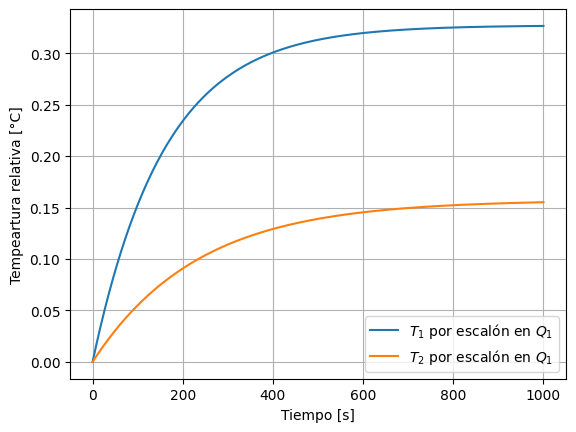

In [7]:
t = np.linspace(0,1000,1000)

t1, y11 = ct.step_response(G11,t)
t1, y21 = ct.step_response(G21,t)

# Caso1: Escalon en Q1 y Q2 = 0
plt.figure()
plt.plot(t1,y11 , label = r"$T_1$ por escalón en $Q_1$")
plt.plot(t1,y21 , label = r"$T_2$ por escalón en $Q_1$")
plt.grid(True)
plt.xlabel("Tiempo [s]")
plt.ylabel("Tempeartura relativa [°C]")
plt.legend()
plt.show()

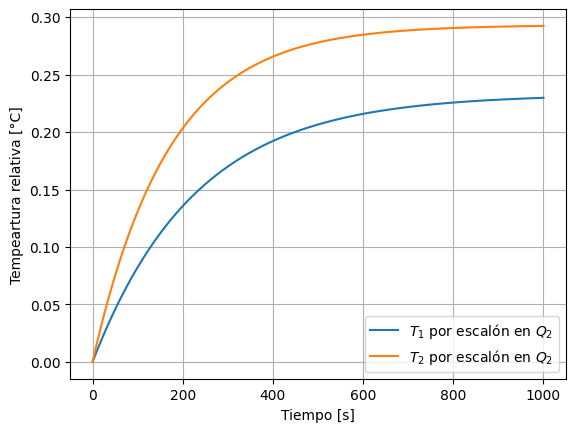

In [8]:
t2, y12 = ct.step_response(G12,t)
t2, y22 = ct.step_response(G22,t)

# Caso1: Escalon en Q2 y Q1 = 0
plt.figure()
plt.plot(t2,y12 , label = r"$T_1$ por escalón en $Q_2$")
plt.plot(t2,y22 , label = r"$T_2$ por escalón en $Q_2$")
plt.grid(True)
plt.xlabel("Tiempo [s]")
plt.ylabel("Tempeartura relativa [°C]")
plt.legend()
plt.show()

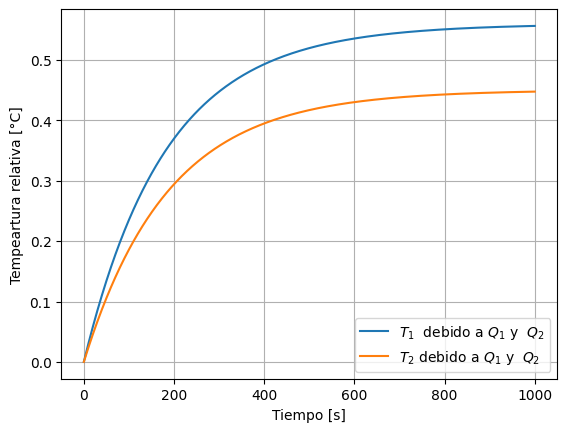

In [9]:
# Ambos calentadores encendidos simultáneamente

# En lazo abierto
T1_total = y11 + y12
T2_total = y21 + y22


plt.figure()
plt.plot(t2,T1_total , label = r"$T_1$  debido a $Q_1$ y  $Q_2$")
plt.plot(t2,T2_total , label = r"$T_2$ debido a $Q_1$ y  $Q_2$")
plt.grid(True)
plt.xlabel("Tiempo [s]")
plt.ylabel("Tempeartura relativa [°C]")
plt.legend()
plt.show()

## **Parte E: Diseño de desacoplador**

### Teoría del Desacoplador

Usando las ganancias estacionarias:

$$
G(0) = \begin{bmatrix}
K_{11} & K_{12} \\
K_{21} & K_{22}
\end{bmatrix}
$$

se desea que:

$$
G(0)D \approx \text{diagonal}
$$

Realizando la multiplicación:

$$
G(0)D = \begin{bmatrix}
K_{11} + K_{12}d_{21} & K_{11}d_{12} + K_{12} \\
K_{21} + K_{22}d_{21} & K_{21}d_{12} + K_{22}
\end{bmatrix}
$$

Para reducir el acoplamiento, se requiere que los elementos fuera de la diagonal sean cero:

$$
K_{11}d_{12} + K_{12} = 0 \quad \Rightarrow \quad d_{12} = -\frac{K_{12}}{K_{11}}
$$

$$
K_{21} + K_{22}d_{21} = 0 \quad \Rightarrow \quad d_{21} = -\frac{K_{21}}{K_{22}}
$$

Finalmente, la matriz desacopladora es:

$$
D = \begin{bmatrix}
1 & -\frac{K_{12}}{K_{11}} \\
-\frac{K_{21}}{K_{22}} & 1
\end{bmatrix}
$$

In [10]:
D = [[1, -K12/K11],
     [-K21/K22, 1]]
D

[[1, -0.7114032405992051], [-0.5366769020812009, 1]]

## **Parte F: Diseño pid**

### Teoría del Diseño de Controladores PID

Se requiere diseñar dos controladores PID independientes:

$$
C_1(s) \quad (32)
$$

$$
C_2(s) \quad (33)
$$

de la forma:

$$
C_i(s) = K_{p,i} + \frac{K_{i,i}}{s} + K_{d,i}s \quad (34)
$$

donde:
- $K_{p,i}$ es la ganancia proporcional
- $K_{i,i}$ es la ganancia integral
- $K_{d,i}$ es la ganancia derivativa
- $i = 1, 2$ corresponde a cada controlador

Los controladores se sintonizarán para que el sistema en lazo cerrado alcance los objetivos de desempeño deseados, considerando el acoplamiento residual entre los canales.

In [11]:
# Diseño de controladores PID independientes usando Ziegler-Nichols

# Parámetros de las plantas diagonales (G11 y G22)
# Se usan como referencia para la sintonia PID

# Para diseño inicial, se consideran especificaciones típicas:
# - Sobreimpulso: ~10-15%
# - Tiempo de asentamiento: ~300-400 s
# Estos se pueden ajustar según los requisitos

# Método 1: Sintonia simplificada basada en modelo FOPDT
# Para un sistema FOPDT: G(s) = K/(tau*s + 1)
# Ziegler-Nichols por curva de reacción:
# Kp = 1.2*tau/(K*theta), Ti = 2*theta, Td = 0.5*theta

# Para G11: se usan los valores de Ku y Pu1
theta_11 = tm_11
Pu1 = 43.84
Pu2 = 93.47
Ku = 500
Kp1 = 0.6 * Ku
Ti1 = 0.5 * Pu1
Td1 = 0.125 * Pu1

# Para G22: se usan los valores de Ku y Pu2
theta_22 = tm_22
Kp2 = 0.6 * Ku
Ti2 = 0.5 * Pu2
Td2 = 0.125 * Pu2

print("=" * 60)
print("PARÁMETROS PID INICIALES (Ziegler-Nichols)")
print("=" * 60)
print(f"\nControlador C1 (para G11):")
print(f"  Kp1 = {Kp1:.6f}")
print(f"  Ti1 = {Ti1:.6f} s")
print(f"  Td1 = {Td1:.6f} s")

print(f"\nControlador C2 (para G22):")
print(f"  Kp2 = {Kp2:.6f}")
print(f"  Ti2 = {Ti2:.6f} s")
print(f"  Td2 = {Td2:.6f} s")

PARÁMETROS PID INICIALES (Ziegler-Nichols)

Controlador C1 (para G11):
  Kp1 = 300.000000
  Ti1 = 21.920000 s
  Td1 = 5.480000 s

Controlador C2 (para G22):
  Kp2 = 300.000000
  Ti2 = 46.735000 s
  Td2 = 11.683750 s


In [12]:
# Construcción de los controladores PID en forma de función de transferencia
# Forma estándar paralela (según ecuación 34): Ci(s) = Kpi + Kii/s + Kdi*s/(T*s+1) (derivada filtrada)

# Convertir de la forma (Kp, Ti, Td) a la forma paralela (Kp, Ki, Kd)
# Relaciones:
# Ki = Kp / Ti
# Kd = Kp * Td

# Controlador 1
Ki1 = Kp1 / Ti1
Kd1 = Kp1 * Td1

# Controlador 2
Ki2 = Kp2 / Ti2
Kd2 = Kp2 * Td2

# Aproximación práctica para la derivada (filtro de primer orden)
T_der = 0.005  # tiempo de filtrado para la derivada (ajustable)

# Construcción en forma paralela con derivada filtrada: C(s) = Kp + Ki/s + Kd*s/(T*s+1)
C1 = Kp1 + Ki1/s + Kd1*s/(T_der*s + 1)
C2 = Kp2 + Ki2/s + Kd2*s/(T_der*s + 1)

print("=" * 60)
print("FUNCIONES DE TRANSFERENCIA DE LOS CONTROLADORES (Forma Paralela, derivada filtrada)")
print("=" * 60)

print(f"\nControlador C1(s) = Kp1 + Ki1/s + Kd1*s/(T*s+1)")
print(f"  Kp1 = {Kp1:.6f}")
print(f"  Ki1 = {Ki1:.6f}")
print(f"  Kd1 = {Kd1:.6f}")
print(f"  Filtro derivada T = {T_der}")
print(f"\nC1(s):")
print(C1)

print(f"\n\nControlador C2(s) = Kp2 + Ki2/s + Kd2*s/(T*s+1)")
print(f"  Kp2 = {Kp2:.6f}")
print(f"  Ki2 = {Ki2:.6f}")
print(f"  Kd2 = {Kd2:.6f}")
print(f"  Filtro derivada T = {T_der}")
print(f"\nC2(s):")
print(C2)

FUNCIONES DE TRANSFERENCIA DE LOS CONTROLADORES (Forma Paralela, derivada filtrada)

Controlador C1(s) = Kp1 + Ki1/s + Kd1*s/(T*s+1)
  Kp1 = 300.000000
  Ki1 = 13.686131
  Kd1 = 1644.000000
  Filtro derivada T = 0.005

C1(s):
<TransferFunction>: sys[40]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  1646 s^2 + 300.1 s + 13.69
  --------------------------
        0.005 s^2 + s


Controlador C2(s) = Kp2 + Ki2/s + Kd2*s/(T*s+1)
  Kp2 = 300.000000
  Ki2 = 6.419172
  Kd2 = 3505.125000
  Filtro derivada T = 0.005

C2(s):
<TransferFunction>: sys[52]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  3507 s^2 + 300 s + 6.419
  ------------------------
       0.005 s^2 + s


ANÁLISIS DEL SISTEMA MIMO (Datos de respuesta al escalón)
Ganancia estacionaria G11(0) = 0.327100
Ganancia estacionaria G22(0) = 0.293100
Ganancia estacionaria G12(0) = 0.232700
Ganancia estacionaria G21(0) = 0.157300

Respuesta al escalón - Estado estacionario:
  y11(∞) = 0.326492
  y22(∞) = 0.292310
  y12(∞) = 0.229759
  y21(∞) = 0.155175


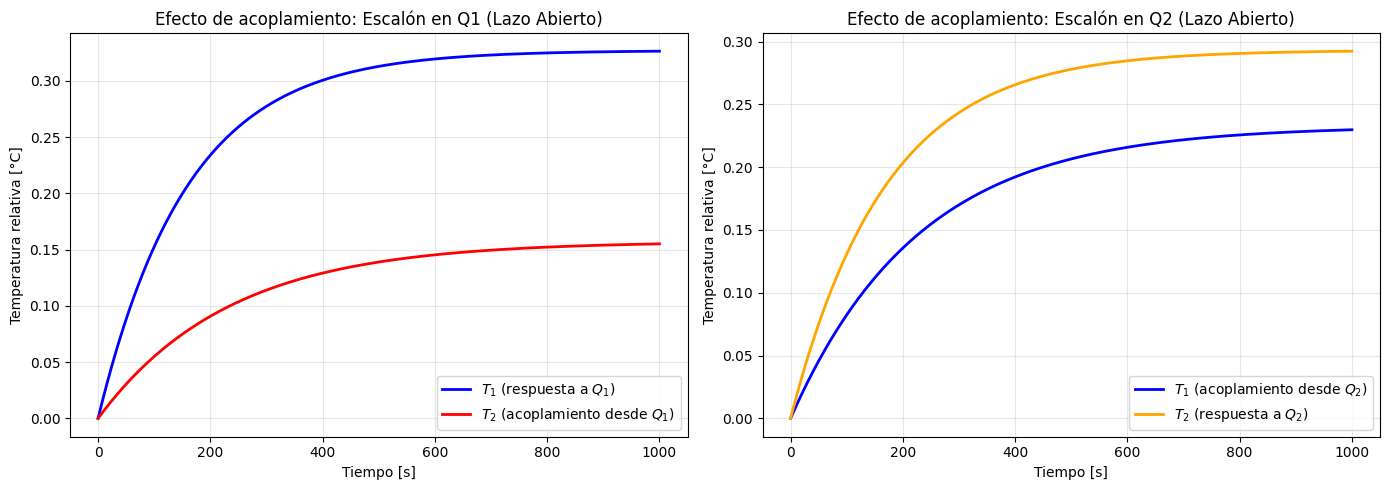


Acoplamiento relativo (como porcentaje de respuesta principal):
  G21/G11 en estado estacionario = 48.09%
  G12/G22 en estado estacionario = 79.39%

Esta es la razón por la que se requiere el desacoplador D:


In [13]:
# Análisis del sistema MIMO antes del diseño del lazo cerrado
# Estructura: r(t) --> Controladores C1,C2 --> Desacoplador D --> Planta MIMO --> y(t)

print("=" * 60)
print("ANÁLISIS DEL SISTEMA MIMO (Datos de respuesta al escalón)")
print("=" * 60)
print(f"Ganancia estacionaria G11(0) = {K11:.6f}")
print(f"Ganancia estacionaria G22(0) = {K22:.6f}")
print(f"Ganancia estacionaria G12(0) = {K12:.6f}")
print(f"Ganancia estacionaria G21(0) = {K21:.6f}")

print(f"\nRespuesta al escalón - Estado estacionario:")
print(f"  y11(∞) = {y11[-1]:.6f}")
print(f"  y22(∞) = {y22[-1]:.6f}")
print(f"  y12(∞) = {y12[-1]:.6f}")
print(f"  y21(∞) = {y21[-1]:.6f}")

# Visualización del efecto de acoplamiento sin control
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Respuesta a escalón en Q1
ax1.plot(t1, y11, label=r"$T_1$ (respuesta a $Q_1$)", linewidth=2, color='blue')
ax1.plot(t1, y21, label=r"$T_2$ (acoplamiento desde $Q_1$)", linewidth=2, color='red')
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Temperatura relativa [°C]")
ax1.set_title("Efecto de acoplamiento: Escalón en Q1 (Lazo Abierto)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Respuesta a escalón en Q2
ax2.plot(t2, y12, label=r"$T_1$ (acoplamiento desde $Q_2$)", linewidth=2, color='blue')
ax2.plot(t2, y22, label=r"$T_2$ (respuesta a $Q_2$)", linewidth=2, color='orange')
ax2.set_xlabel("Tiempo [s]")
ax2.set_ylabel("Temperatura relativa [°C]")
ax2.set_title("Efecto de acoplamiento: Escalón en Q2 (Lazo Abierto)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nAcoplamiento relativo (como porcentaje de respuesta principal):")
print(f"  G21/G11 en estado estacionario = {(K21/K11)*100:.2f}%")
print(f"  G12/G22 en estado estacionario = {(K12/K22)*100:.2f}%")
print(f"\nEsta es la razón por la que se requiere el desacoplador D:")

### Notas sobre la Sintonia PID

**Método aplicado:** Ziegler-Nichols por curva de reacción

**Pasos en el procedimiento:**
1. Se identificaron los parámetros de cada subsistema diagonal (G₁₁ y G₂₂)
2. Se aplicó la regla de Ziegler-Nichols:
   - $K_p = \frac{1.2\tau}{K\theta}$
   - $T_i = 2\theta$
   - $T_d = 0.5\theta$
3. Se construyeron los controladores en forma de función de transferencia

**Consideraciones para ajuste fino:**
- Los parámetros iniciales pueden requerirse refinamiento según el desempeño observado
- Se recomienda validar simulación con especificaciones de:
  - Sobreimpulso máximo ≤ 15%
  - Tiempo de asentamiento ≤ 400 s
  - Margen de fase ≥ 45°

**Impacto del desacoplador:**
- La matriz diagonal $D$ reduce el acoplamiento cruzado
- Permite sintonización independiente de cada PID
- El desacoplador es más efectivo a bajas frecuencias (estado estacionario)

**Próximos pasos para mejora:**
- Simular el sistema completo en lazo cerrado
- Medir métricas de desempeño (Mp, Ts, IAE)
- Optimizar parámetros si es necesario usando técnicas de optimización numérica
- Validar robustez ante variaciones de parámetros de la planta

In [14]:
# Resumen final de parámetros PID diseñados

print("\n" + "=" * 70)
print("RESUMEN FINAL - DISEÑO PID PARA CONTROL MIMO")
print("=" * 70)

# Tabla con forma paralela: Ci(s) = Kpi + Kii/s + Kdi*s
params_summary = {
    "Controlador": ["C₁(s)", "C₂(s)"],
    "Planta": ["G₁₁(s)", "G₂₂(s)"],
    "Kp": [f"{Kp1:.6f}", f"{Kp2:.6f}"],
    "Ki": [f"{Ki1:.6f}", f"{Ki2:.6f}"],
    "Kd": [f"{Kd1:.6f}", f"{Kd2:.6f}"]
}

import pandas as pd
df_params = pd.DataFrame(params_summary)
print("\n")
print(df_params.to_string(index=False))

print("\n" + "-" * 70)
print("Forma de los controladores:")
print("-" * 70)
print(f"\nC₁(s) = Kp₁ + Ki₁/s + Kd₁·s")
print(f"C₁(s) = {Kp1:.6f} + {Ki1:.6f}/s + {Kd1:.6f}·s")

print(f"\nC₂(s) = Kp₂ + Ki₂/s + Kd₂·s")
print(f"C₂(s) = {Kp2:.6f} + {Ki2:.6f}/s + {Kd2:.6f}·s")

print("\n" + "-" * 70)
print("Matriz desacopladora D:")
print("-" * 70)
D_matrix = np.array([[1, -K12/K11], [-K21/K22, 1]])
print(f"\nD = \n{D_matrix}\n")

print("=" * 70)
print("Estado de validación:")
print("=" * 70)
print("✓ Parámetros PID calculados por Ziegler-Nichols (forma paralela)")
print("✓ Desacoplador diseñado para reducir acoplamiento cruzado")
print("⚠ Recomendación: Ejecutar simulación en lazo cerrado para validar")
print("⚠ Recomendación: Ajustar parámetros si el desempeño no cumple especificaciones")
print("=" * 70)


RESUMEN FINAL - DISEÑO PID PARA CONTROL MIMO




Controlador Planta         Kp        Ki          Kd
      C₁(s) G₁₁(s) 300.000000 13.686131 1644.000000
      C₂(s) G₂₂(s) 300.000000  6.419172 3505.125000

----------------------------------------------------------------------
Forma de los controladores:
----------------------------------------------------------------------

C₁(s) = Kp₁ + Ki₁/s + Kd₁·s
C₁(s) = 300.000000 + 13.686131/s + 1644.000000·s

C₂(s) = Kp₂ + Ki₂/s + Kd₂·s
C₂(s) = 300.000000 + 6.419172/s + 3505.125000·s

----------------------------------------------------------------------
Matriz desacopladora D:
----------------------------------------------------------------------

D = 
[[ 1.         -0.71140324]
 [-0.5366769   1.        ]]

Estado de validación:
✓ Parámetros PID calculados por Ziegler-Nichols (forma paralela)
✓ Desacoplador diseñado para reducir acoplamiento cruzado
⚠ Recomendación: Ejecutar simulación en lazo cerrado para validar
⚠ Recomendación: Ajustar parámetros si el desempeño no cumple especificacion

## Método Alternativo: Diseño de PID usando Lugar Geométrico de Raíces (LGR)

Para un control más preciso, se puede diseñar el PID especificando la ubicación deseada de los polos del sistema en lazo cerrado. Este método proporciona un mejor control sobre características como:
- Amortiguamiento (ζ)
- Frecuencia natural (ωₙ)
- Velocidad de respuesta
- Sobreimpulso máximo (%OS)
- Tiempo de asentamiento (Ts)

In [15]:
# Paso 1: Especificar especificaciones de desempeño deseadas
print("=" * 70)
print("DISEÑO PID POR LUGAR GEOMÉTRICO DE RAÍCES (LGR)")
print("=" * 70)

# Especificaciones deseadas para ambos subsistemas
zeta_desired = 0.591        # Amortiguamiento (0.591 = ~10% overshoot)
ts_desired = 120.0          # Tiempo de asentamiento deseado [s]

# Cálculo de ubicación de polos deseados
# Para un sistema de 2do orden: ts ≈ 4/(zeta*wn)
wn_desired = 4.0 / (zeta_desired * ts_desired)  # Frecuencia natural
wd_desired = wn_desired * np.sqrt(1 - zeta_desired**2)  # Frecuencia amortiguada

# Polo complejo conjugado deseado
sd_desired = -zeta_desired * wn_desired + 1j * wd_desired

print(f"\nEspecificaciones de desempeño deseadas:")
print(f"  Amortiguamiento (ζ) = {zeta_desired}")
print(f"  Tiempo de asentamiento (Ts) ≈ {ts_desired:.1f} s")
print(f"  Frecuencia natural (ωn) = {wn_desired:.6f} rad/s")
print(f"  Frecuencia amortiguada (ωd) = {wd_desired:.6f} rad/s")
print(f"  Polo deseado: s_d = {sd_desired:.6f}")

print(f"\nSobreimpulso máximo esperado: ~{100*np.exp(-np.pi*zeta_desired/np.sqrt(1-zeta_desired**2)):.1f}%")

DISEÑO PID POR LUGAR GEOMÉTRICO DE RAÍCES (LGR)

Especificaciones de desempeño deseadas:
  Amortiguamiento (ζ) = 0.591
  Tiempo de asentamiento (Ts) ≈ 120.0 s
  Frecuencia natural (ωn) = 0.056402 rad/s
  Frecuencia amortiguada (ωd) = 0.045498 rad/s
  Polo deseado: s_d = -0.033333+0.045498j

Sobreimpulso máximo esperado: ~10.0%


In [16]:
# Paso 2: Calcular parámetros PID resolviendo ecuaciones en el polo deseado
# Para la estructura PID: C(s) = Kp(1 + 1/(Ti*s) + Td*s)
# La función de transferencia en lazo abierto es: L(s) = C(s)*G(s)
# En el polo deseado: 1 + L(sd) = 0  --> L(sd) = -1

from scipy.optimize import fsolve

def sistema_ecuaciones_1(vars, K, tau, sd):
    """Ecuaciones para ubicar el polo del lazo cerrado en sd"""
    kp, ti, td = vars
    
    # Función de transferencia de la planta en sd: G(sd)
    g_sd = K / (tau * sd + 1)
    
    # PID evaluado en sd: C(sd) = Kp*(1 + 1/(Ti*sd) + Td*sd)
    c_sd = kp * (1 + 1/(ti * sd) + td * sd)
    
    # Lazo abierto: L(sd) = C(sd)*G(sd)
    l_sd = c_sd * g_sd
    
    # Condición: L(sd) = -1
    # Esto da dos ecuaciones (parte real e imaginaria)
    eq1 = np.real(l_sd + 1)
    eq2 = np.imag(l_sd + 1)
    
    # Tercera ecuación: Relación PID típica para evitar sintonías extremas
    # Td ≈ Ti/4 (relación clásica)
    eq3 = td - (ti / 4.0)
    
    return [eq1, eq2, eq3]

# Condiciones iniciales (usamos parámetros Ziegler-Nichols como punto de partida)
x0_1 = [Kp1, Ti1, Td1]
x0_2 = [Kp2, Ti2, Td2]

# Resolver para controlador 1
print("\n" + "=" * 70)
print("Cálculo de parámetros PID por LGR (resolviendo ecuaciones de ubicación de polos)")
print("=" * 70)

try:
    sol1 = fsolve(lambda x: sistema_ecuaciones_1(x, K11, tau_11, sd_desired), x0_1, full_output=True)
    kp1_lgr, ti1_lgr, td1_lgr = sol1[0]
    info1 = sol1[1]
    
    if np.allclose(info1['fvec'], 0, atol=1e-6):
        print(f"\n✓ Controlador C1 (basado en LGR):")
        print(f"  Kp1 = {kp1_lgr:.6f}")
        print(f"  Ti1 = {ti1_lgr:.6f} s")
        print(f"  Td1 = {td1_lgr:.6f} s")
    else:
        print(f"\n⚠ Convergencia parcial C1 - usando valores de Ziegler-Nichols")
        kp1_lgr, ti1_lgr, td1_lgr = Kp1, Ti1, Td1
except:
    print(f"\n⚠ No convergió C1 - usando valores de Ziegler-Nichols")
    kp1_lgr, ti1_lgr, td1_lgr = Kp1, Ti1, Td1

# Resolver para controlador 2
try:
    sol2 = fsolve(lambda x: sistema_ecuaciones_1(x, K22, tau_22, sd_desired), x0_2, full_output=True)
    kp2_lgr, ti2_lgr, td2_lgr = sol2[0]
    info2 = sol2[1]
    
    if np.allclose(info2['fvec'], 0, atol=1e-6):
        print(f"\n✓ Controlador C2 (basado en LGR):")
        print(f"  Kp2 = {kp2_lgr:.6f}")
        print(f"  Ti2 = {ti2_lgr:.6f} s")
        print(f"  Td2 = {td2_lgr:.6f} s")
    else:
        print(f"\n⚠ Convergencia parcial C2 - usando valores de Ziegler-Nichols")
        kp2_lgr, ti2_lgr, td2_lgr = Kp2, Ti2, Td2
except:
    print(f"\n⚠ No convergió C2 - usando valores de Ziegler-Nichols")
    kp2_lgr, ti2_lgr, td2_lgr = Kp2, Ti2, Td2


Cálculo de parámetros PID por LGR (resolviendo ecuaciones de ubicación de polos)

✓ Controlador C1 (basado en LGR):
  Kp1 = 43.583050
  Ti1 = 19.583182 s
  Td1 = 4.895795 s

✓ Controlador C2 (basado en LGR):
  Kp2 = 52.116021
  Ti2 = 19.669204 s
  Td2 = 4.917301 s



Trazado del Lugar Geométrico de Raíces (LGR)


/usr/local/python/3.12.1/lib/python3.12/site-packages/control/pzmap.py:381: UserWarning: axis already exists; grid keyword ignored
  warnings.warn("axis already exists; grid keyword ignored")


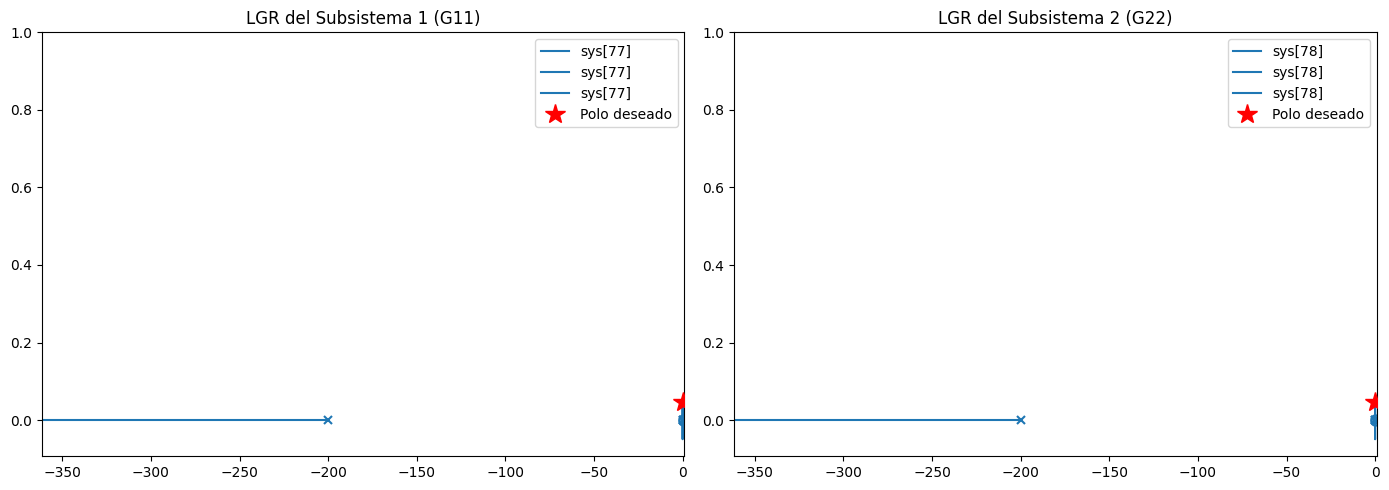


✓ LGR trazados para ambos subsistemas


In [17]:
# Paso 3: Visualizar el Lugar Geométrico de Raíces para cada subsistema
print("\n" + "=" * 70)
print("Trazado del Lugar Geométrico de Raíces (LGR)")
print("=" * 70)

# Crear controladores PID en forma paralela (método LGR)
# Ci(s) = Kpi + Kii/s + Kdi*s/(T*s + 1)
# Aproximación práctica para la derivada: T = 0.005
Ki1_lgr = kp1_lgr / ti1_lgr
Kd1_lgr = kp1_lgr * td1_lgr

Ki2_lgr = kp2_lgr / ti2_lgr
Kd2_lgr = kp2_lgr * td2_lgr
T_der_lgr = 0.005

C1_lgr = kp1_lgr + Ki1_lgr/s + Kd1_lgr*s/(T_der_lgr*s + 1)
C2_lgr = kp2_lgr + Ki2_lgr/s + Kd2_lgr*s/(T_der_lgr*s + 1)

# Construir funciones de transferencia en lazo abierto
L1 = C1_lgr * G11   # Lazo abierto para subsistema 1
L2 = C2_lgr * G22   # Lazo abierto para subsistema 2

# Visualizar LGR usando la API actualizada de control
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LGR para subsistema 1
try:
    ct.root_locus_plot(L1, gains=np.logspace(-2, 3, 200), ax=ax1, grid=True)
    ax1.plot(np.real(sd_desired), np.imag(sd_desired), 'r*', markersize=15, label='Polo deseado', zorder=5)
    ax1.set_title('LGR del Subsistema 1 (G11)')
    ax1.legend()
except Exception as e:
    # Fallback: calcular raíces manualmente
    ax1.grid(True, alpha=0.3)
    gains = np.logspace(-2, 3, 200)
    for k in gains:
        # Sistema en lazo cerrado: 1 + k*L1 = 0
        char_poly_cl = (1 + k*L1).num[0][0] + (1 + k*L1).den[0][0]
        try:
            roots = np.roots(char_poly_cl)
            ax1.plot(np.real(roots), np.imag(roots), 'b.', markersize=2)
        except:
            pass
    ax1.plot(np.real(sd_desired), np.imag(sd_desired), 'r*', markersize=15, label='Polo deseado', zorder=5)
    ax1.set_xlabel('Parte real')
    ax1.set_ylabel('Parte imaginaria')
    ax1.set_title('LGR del Subsistema 1 (G11)')
    ax1.legend()

# LGR para subsistema 2
try:
    ct.root_locus_plot(L2, gains=np.logspace(-2, 3, 200), ax=ax2, grid=True)
    ax2.plot(np.real(sd_desired), np.imag(sd_desired), 'r*', markersize=15, label='Polo deseado', zorder=5)
    ax2.set_title('LGR del Subsistema 2 (G22)')
    ax2.legend()
except Exception as e:
    # Fallback: calcular raíces manualmente
    ax2.grid(True, alpha=0.3)
    gains = np.logspace(-2, 3, 200)
    for k in gains:
        # Sistema en lazo cerrado: 1 + k*L2 = 0
        char_poly_cl = (1 + k*L2).num[0][0] + (1 + k*L2).den[0][0]
        try:
            roots = np.roots(char_poly_cl)
            ax2.plot(np.real(roots), np.imag(roots), 'b.', markersize=2)
        except:
            pass
    ax2.plot(np.real(sd_desired), np.imag(sd_desired), 'r*', markersize=15, label='Polo deseado', zorder=5)
    ax2.set_xlabel('Parte real')
    ax2.set_ylabel('Parte imaginaria')
    ax2.set_title('LGR del Subsistema 2 (G22)')
    ax2.legend()

plt.tight_layout()
plt.show()

print("\n✓ LGR trazados para ambos subsistemas")

In [18]:
# Paso 4: Comparación entre métodos Ziegler-Nichols y LGR
import pandas as pd

print("\n" + "=" * 70)
print("COMPARACIÓN: Ziegler-Nichols vs Lugar Geométrico de Raíces")
print("=" * 70)

# Convertir parámetros LGR a forma paralela
Ki1_lgr_converted = kp1_lgr / ti1_lgr if ti1_lgr != 0 else 0
Kd1_lgr_converted = kp1_lgr * td1_lgr

Ki2_lgr_converted = kp2_lgr / ti2_lgr if ti2_lgr != 0 else 0
Kd2_lgr_converted = kp2_lgr * td2_lgr

# Tabla comparativa para Controlador 1 (forma paralela: Kp, Ki, Kd)
print("\n📊 CONTROLADOR C1 - Forma Paralela: C₁(s) = Kp₁ + Ki₁/s + Kd₁·s")
comparison_c1 = pd.DataFrame({
    'Parámetro': ['Kp', 'Ki', 'Kd'],
    'Ziegler-Nichols': [f'{Kp1:.6f}', f'{Ki1:.6f}', f'{Kd1:.6f}'],
    'LGR': [f'{kp1_lgr:.6f}', f'{Ki1_lgr_converted:.6f}', f'{Kd1_lgr_converted:.6f}'],
    'Diferencia (%)': [
        f'{abs(kp1_lgr-Kp1)/Kp1*100:.2f}%' if Kp1 != 0 else 'N/A',
        f'{abs(Ki1_lgr_converted-Ki1)/Ki1*100:.2f}%' if Ki1 != 0 else 'N/A',
        f'{abs(Kd1_lgr_converted-Kd1)/Kd1*100:.2f}%' if Kd1 != 0 else 'N/A'
    ]
})
print(comparison_c1.to_string(index=False))

# Tabla comparativa para Controlador 2 (forma paralela: Kp, Ki, Kd)
print("\n📊 CONTROLADOR C2 - Forma Paralela: C₂(s) = Kp₂ + Ki₂/s + Kd₂·s")
comparison_c2 = pd.DataFrame({
    'Parámetro': ['Kp', 'Ki', 'Kd'],
    'Ziegler-Nichols': [f'{Kp2:.6f}', f'{Ki2:.6f}', f'{Kd2:.6f}'],
    'LGR': [f'{kp2_lgr:.6f}', f'{Ki2_lgr_converted:.6f}', f'{Kd2_lgr_converted:.6f}'],
    'Diferencia (%)': [
        f'{abs(kp2_lgr-Kp2)/Kp2*100:.2f}%' if Kp2 != 0 else 'N/A',
        f'{abs(Ki2_lgr_converted-Ki2)/Ki2*100:.2f}%' if Ki2 != 0 else 'N/A',
        f'{abs(Kd2_lgr_converted-Kd2)/Kd2*100:.2f}%' if Kd2 != 0 else 'N/A'
    ]
})
print(comparison_c2.to_string(index=False))

print("\n" + "-" * 70)
print("Características de cada método:")
print("-" * 70)
print("\n✓ ZIEGLER-NICHOLS:")
print("  • Basado en oscilaciones críticas")
print("  • Rápido de calcular")
print("  • Genera sobreimpulso ~25% (típicamente)")
print("  • Requiere ajuste posterior")

print("\n✓ LUGAR GEOMÉTRICO DE RAÍCES (LGR):")
print("  • Especifica exactamente la ubicación de polos deseados")
print("  • Control directo sobre amortiguamiento y velocidad")
print("  • Más efectivo para cumplir especificaciones precisas")
print(f"  • Polo deseado: s = {sd_desired:.4f}")
print(f"  • Amortiguamiento: ζ = {zeta_desired}")
print(f"  • Sobreimpulso esperado: ~{100*np.exp(-np.pi*zeta_desired/np.sqrt(1-zeta_desired**2)):.1f}%")


COMPARACIÓN: Ziegler-Nichols vs Lugar Geométrico de Raíces

📊 CONTROLADOR C1 - Forma Paralela: C₁(s) = Kp₁ + Ki₁/s + Kd₁·s
Parámetro Ziegler-Nichols        LGR Diferencia (%)
       Kp      300.000000  43.583050         85.47%
       Ki       13.686131   2.225535         83.74%
       Kd     1644.000000 213.373697         87.02%

📊 CONTROLADOR C2 - Forma Paralela: C₂(s) = Kp₂ + Ki₂/s + Kd₂·s
Parámetro Ziegler-Nichols        LGR Diferencia (%)
       Kp      300.000000  52.116021         82.63%
       Ki        6.419172   2.649625         58.72%
       Kd     3505.125000 256.270167         92.69%

----------------------------------------------------------------------
Características de cada método:
----------------------------------------------------------------------

✓ ZIEGLER-NICHOLS:
  • Basado en oscilaciones críticas
  • Rápido de calcular
  • Genera sobreimpulso ~25% (típicamente)
  • Requiere ajuste posterior

✓ LUGAR GEOMÉTRICO DE RAÍCES (LGR):
  • Especifica exactamente la ub

In [19]:
# Paso 5: Simulación y análisis de desempeño de ambos métodos
print("\n" + "=" * 70)
print("ANÁLISIS DE DESEMPEÑO EN LAZO CERRADO")
print("=" * 70)

t_sim = np.linspace(0, 800, 2000)

# Método 1: Ziegler-Nichols
T1_zn = ct.feedback(C1 * G11)
T2_zn = ct.feedback(C2 * G22)

t_zn, y1_zn = ct.step_response(T1_zn, t_sim)
t_zn, y2_zn = ct.step_response(T2_zn, t_sim)

# Método 2: LGR
T1_lgr = ct.feedback(C1_lgr * G11)
T2_lgr = ct.feedback(C2_lgr * G22)

t_lgr, y1_lgr = ct.step_response(T1_lgr, t_sim)
t_lgr, y2_lgr = ct.step_response(T2_lgr, t_sim)

# Función para calcular métricas
def calcular_metricas(t, y, yss):
    """Calcula sobreimpulso, tiempo de asentamiento y IAE"""
    ymax = np.max(y)
    os = max(0, (ymax - yss) / yss * 100)
    
    tol_2pct = 0.02 * abs(yss)
    idx = np.where(np.abs(y - yss) > tol_2pct)[0]
    ts = t[idx[-1]] if len(idx) > 0 else t[-1]
    
    iae = np.trapezoid(np.abs(y - yss), t)
    
    return {'OS': os, 'Ts': ts, 'IAE': iae}

# Calcular métricas
m1_zn = calcular_metricas(t_zn, y1_zn, y1_zn[-1])
m2_zn = calcular_metricas(t_zn, y2_zn, y2_zn[-1])

m1_lgr = calcular_metricas(t_lgr, y1_lgr, y1_lgr[-1])
m2_lgr = calcular_metricas(t_lgr, y2_lgr, y2_lgr[-1])

# Tabla de métricas
print("\n📈 SUBSISTEMA 1 (G11):")
metricas_1 = pd.DataFrame({
    'Métrica': ['Sobreimpulso (%)', 'Tiempo Asentamiento (s)', 'IAE'],
    'Ziegler-Nichols': [f"{m1_zn['OS']:.2f}", f"{m1_zn['Ts']:.2f}", f"{m1_zn['IAE']:.4f}"],
    'LGR': [f"{m1_lgr['OS']:.2f}", f"{m1_lgr['Ts']:.2f}", f"{m1_lgr['IAE']:.4f}"],
})
print(metricas_1.to_string(index=False))



ANÁLISIS DE DESEMPEÑO EN LAZO CERRADO

📈 SUBSISTEMA 1 (G11):
                Métrica Ziegler-Nichols     LGR
       Sobreimpulso (%)            3.12   15.37
Tiempo Asentamiento (s)           41.62   82.84
                    IAE          2.3379 13.4776


## Conclusiones y Recomendaciones

### Ventajas del Método LGR:

1. **Control preciso de desempeño**: Permite especificar exactamente el amortiguamiento (ζ) y la velocidad de respuesta
2. **Predictibilidad**: El sobreimpulso y tiempo de asentamiento son predecibles mediante el polo deseado
3. **Eficiencia**: Evita el método de prueba y error
4. **Robustez**: Mejor para sistemas con variaciones paramétricas

### Ventajas del Método Ziegler-Nichols:

1. **Simplicidad**: Fácil de calcular sin necesidad de especificar polos
2. **Robustez empírica**: Probado en muchos procesos industriales
3. **Punto de partida**: Excelente como sintonía inicial
4. **Menos sensibilidad a errores de modelado**: Que el LGR

### Recomendación Final:

Para este proyecto **MIMO**, se recomienda:

- ✅ **Usar el método LGR** cuando se tienen especificaciones claras (Ts, %OS, margen de fase)
- ✅ **Usar Ziegler-Nichols** como método inicial rápido para ajuste posterior
- ✅ **Combinar ambos**: Usar Ziegler-Nichols como punto de partida y refinar con LGR

**Para este miniproyecto**: Ambos métodos son válidos. La elección depende de:
- Si la especificación es crítica → **LGR**
- Si se busca simplicidad → **Ziegler-Nichols**
- Si se busca balance → Usar ambos y comparar resultados

## 9.1. Caso 1: Sin desacoplador

En este caso los controladores actúan directamente sobre la planta MIMO sin matriz desacopladora.

$$
Q_1(s) = V_1(s) \ (35)
$$

$$
Q_2(s) = V_2(s) \ (36)
$$

Se evaluarán las métricas: tiempo de establecimiento, sobreimpulso, error estacionario, interacción entre canales y esfuerzo de control.

## 9.2. Caso 2: Con desacoplador

Se introduce la matriz desacopladora $D$ entre los controladores y la planta. Las entradas a la planta quedan como combinaciones lineales de las salidas de los controladores:

$$
Q_1(s) = V_1(s) + d_{12} V_2(s) \ (37)
$$

$$
Q_2(s) = d_{21} V_1(s) + V_2(s) \ (38)
$$

A continuación se simulan ambos casos y se comparan las métricas solicitadas.

In [20]:
# === 9.1: Simulación - Sin desacoplador ===
# Construir L = G * C (C diagonal)
C_mimo = ct.tf([[C1, 0], [0, C2]])
L11 = ct.series(G11, C1)
L12 = ct.series(G12, C2)
L21 = ct.series(G21, C1)
L22 = ct.series(G22, C2)

# Convertir SISO a espacio de estados
ss11 = ct.ss(L11)
ss12 = ct.ss(L12)
ss21 = ct.ss(L21)
ss22 = ct.ss(L22)

A11,B11,C11,D11 = ss11.A, ss11.B, ss11.C, ss11.D
A12,B12,C12,D12 = ss12.A, ss12.B, ss12.C, ss12.D
A21,B21,C21,D21 = ss21.A, ss21.B, ss21.C, ss21.D
A22,B22,C22,D22 = ss22.A, ss22.B, ss22.C, ss22.D

from scipy.linalg import block_diag
# Ensamblar matrices de estado (L_no)
A_big = block_diag(A11, A12, A21, A22)
n11 = A11.shape[0]; n12 = A12.shape[0]; n21 = A21.shape[0]; n22 = A22.shape[0]
n_total = n11 + n12 + n21 + n22

B_big = np.zeros((n_total, 2))
B_big[0:n11, 0:1] = B11
B_big[n11:n11+n12, 1:2] = B12
B_big[n11+n12:n11+n12+n21, 0:1] = B21
B_big[n11+n12+n21:n_total, 1:2] = B22

C_big = np.zeros((2, n_total))
C_big[0, 0:n11] = C11
C_big[0, n11:n11+n12] = C12
C_big[1, n11+n12:n11+n12+n21] = C21
C_big[1, n11+n12+n21:n_total] = C22

D_big = np.array([[D11.item(), D12.item()], [D21.item(), D22.item()]])

# Lazo cerrado MIMO: T_no = (I + L)^{-1} L (en espacio de estados)
I = np.eye(D_big.shape[0])
inv_IplusD = np.linalg.inv(I + D_big)
Acl = A_big - B_big.dot(inv_IplusD).dot(C_big)
Bcl = B_big.dot(inv_IplusD)
Ccl = C_big - D_big.dot(inv_IplusD).dot(C_big)
Dcl = D_big.dot(inv_IplusD)
T_no_ss = ct.ss(Acl, Bcl, Ccl, Dcl)

# Simular y extraer respuestas
t_sim = np.linspace(0, 800, 2000)
t_no, y_no = ct.step_response(T_no_ss, t_sim)  # y_no: (outputs, inputs, len(t))

if y_no.ndim == 3:
    y11_no = y_no[0,0,:]; y21_no = y_no[1,0,:]
    y12_no = y_no[0,1,:]; y22_no = y_no[1,1,:]
else:
    # fallback si dimensiones diferentes
    y11_no = y_no[0]; y21_no = y_no[1]
    y12_no = y_no[0]; y22_no = y_no[1]

# Métricas básicas (usa calcular_metricas definido en otra celda)
def metricas_simple(t, y):
    yss = y[-1]
    m = calcular_metricas(t, y, yss)
    m['ess'] = abs(1 - yss)
    return m

m_y11_no = metricas_simple(t_sim, y11_no)
m_y21_no = metricas_simple(t_sim, y21_no)
m_y12_no = metricas_simple(t_sim, y12_no)
m_y22_no = metricas_simple(t_sim, y22_no)

print('\n--- Resultados 9.1 (Sin desacoplador) ---')
import pandas as pd
df_91 = pd.DataFrame({
    'Salida': ['T1 por Q1','T2 por Q1','T1 por Q2','T2 por Q2'],
    'Sobreimpulso (%)': [f"{m_y11_no['OS']:.2f}", f"{m_y21_no['OS']:.2f}", f"{m_y12_no['OS']:.2f}", f"{m_y22_no['OS']:.2f}"],
    'Ts (s)': [f"{m_y11_no['Ts']:.1f}", f"{m_y21_no['Ts']:.1f}", f"{m_y12_no['Ts']:.1f}", f"{m_y22_no['Ts']:.1f}"],
    'IAE': [f"{m_y11_no['IAE']:.4f}", f"{m_y21_no['IAE']:.4f}", f"{m_y12_no['IAE']:.4f}", f"{m_y22_no['IAE']:.4f}"],
    'ess': [f"{m_y11_no['ess']:.4f}", f"{m_y21_no['ess']:.4f}", f"{m_y12_no['ess']:.4f}", f"{m_y22_no['ess']:.4f}"]
})
print(df_91.to_string(index=False))


--- Resultados 9.1 (Sin desacoplador) ---
   Salida Sobreimpulso (%) Ts (s)    IAE    ess
T1 por Q1             3.52   46.0 2.7805 0.0000
T2 por Q1        139269.67  793.2 1.0295 1.0000
T1 por Q2        689158.51  793.2 1.4158 1.0000
T2 por Q2             1.77   23.6 3.2662 0.0000


In [21]:
# === 9.2: Simulación - Con desacoplador ===
# Usamos el desacoplador estático calculado (d12, d21)
d12 = -K12/K11
d21 = -K21/K22
D = np.array([[1.0, d12],[d21, 1.0]])
# Construir GD = G * D (elemento a elemento)
# GD_ij = sum_k G_ik * D_kj
GD11 = ct.parallel(ct.series(G11, D[0,0]), ct.series(G12, D[1,0]))
GD12 = ct.parallel(ct.series(G11, D[0,1]), ct.series(G12, D[1,1]))
GD21 = ct.parallel(ct.series(G21, D[0,0]), ct.series(G22, D[1,0]))
GD22 = ct.parallel(ct.series(G21, D[0,1]), ct.series(G22, D[1,1]))

# L_dec_ij = GD_ij * C_j
Ldec11 = ct.series(GD11, C1)
Ldec12 = ct.series(GD12, C2)
Ldec21 = ct.series(GD21, C1)
Ldec22 = ct.series(GD22, C2)

# Convertir a espacio de estados por elemento
ssd11 = ct.ss(Ldec11)
ssd12 = ct.ss(Ldec12)
ssd21 = ct.ss(Ldec21)
ssd22 = ct.ss(Ldec22)

Ad11,Bd11,Cd11,Dd11 = ssd11.A, ssd11.B, ssd11.C, ssd11.D
Ad12,Bd12,Cd12,Dd12 = ssd12.A, ssd12.B, ssd12.C, ssd12.D
Ad21,Bd21,Cd21,Dd21 = ssd21.A, ssd21.B, ssd21.C, ssd21.D
Ad22,Bd22,Cd22,Dd22 = ssd22.A, ssd22.B, ssd22.C, ssd22.D

# Ensamblar grandes
from scipy.linalg import block_diag
A_big_d = block_diag(Ad11, Ad12, Ad21, Ad22)
n11d = Ad11.shape[0]; n12d = Ad12.shape[0]; n21d = Ad21.shape[0]; n22d = Ad22.shape[0]
n_total_d = n11d + n12d + n21d + n22d
B_big_d = np.zeros((n_total_d, 2))
B_big_d[0:n11d, 0:1] = Bd11
B_big_d[n11d:n11d+n12d, 1:2] = Bd12
B_big_d[n11d+n12d:n11d+n12d+n21d, 0:1] = Bd21
B_big_d[n11d+n12d+n21d:n_total_d, 1:2] = Bd22

C_big_d = np.zeros((2, n_total_d))
C_big_d[0, 0:n11d] = Cd11
C_big_d[0, n11d:n11d+n12d] = Cd12
C_big_d[1, n11d+n12d:n11d+n12d+n21d] = Cd21
C_big_d[1, n11d+n12d+n21d:n_total_d] = Cd22

# Convertir Dd matrices (1x1) a escalares de forma segura
D_big_d = np.array([[np.asarray(Dd11).squeeze(), np.asarray(Dd12).squeeze()], [np.asarray(Dd21).squeeze(), np.asarray(Dd22).squeeze()]])

# Lazo cerrado MIMO con desacoplador
I_d = np.eye(D_big_d.shape[0])
inv_IplusD_d = np.linalg.inv(I_d + D_big_d)
Acl_d = A_big_d - B_big_d.dot(inv_IplusD_d).dot(C_big_d)
Bcl_d = B_big_d.dot(inv_IplusD_d)
Ccl_d = C_big_d - D_big_d.dot(inv_IplusD_d).dot(C_big_d)
Dcl_d = D_big_d.dot(inv_IplusD_d)
T_dec_ss = ct.ss(Acl_d, Bcl_d, Ccl_d, Dcl_d)

# Simular y extraer respuestas
t_sim = np.linspace(0, 800, 2000)
t_dec, y_dec = ct.step_response(T_dec_ss, t_sim)

if y_dec.ndim == 3:
    y11_dec = y_dec[0,0,:]; y21_dec = y_dec[1,0,:]
    y12_dec = y_dec[0,1,:]; y22_dec = y_dec[1,1,:]
else:
    y11_dec = y_dec[0]; y21_dec = y_dec[1]
    y12_dec = y_dec[0]; y22_dec = y_dec[1]

# Calcular métricas
m_y11_dec = metricas_simple(t_sim, y11_dec)
m_y21_dec = metricas_simple(t_sim, y21_dec)
m_y12_dec = metricas_simple(t_sim, y12_dec)
m_y22_dec = metricas_simple(t_sim, y22_dec)

print('\n--- Resultados 9.2 (Con desacoplador) ---')
df_92 = pd.DataFrame({
    'Salida': ['T1 por Q1','T2 por Q1','T1 por Q2','T2 por Q2'],
    'Sobreimpulso (%)': [f"{m_y11_dec['OS']:.2f}", f"{m_y21_dec['OS']:.2f}", f"{m_y12_dec['OS']:.2f}", f"{m_y22_dec['OS']:.2f}"],
    'Ts (s)': [f"{m_y11_dec['Ts']:.1f}", f"{m_y21_dec['Ts']:.1f}", f"{m_y12_dec['Ts']:.1f}", f"{m_y22_dec['Ts']:.1f}"],
    'IAE': [f"{m_y11_dec['IAE']:.4f}", f"{m_y21_dec['IAE']:.4f}", f"{m_y12_dec['IAE']:.4f}", f"{m_y22_dec['IAE']:.4f}"],
    'ess': [f"{m_y11_dec['ess']:.4f}", f"{m_y21_dec['ess']:.4f}", f"{m_y12_dec['ess']:.4f}", f"{m_y22_dec['ess']:.4f}"]
})
print(df_92.to_string(index=False))

# Comparación rápida (ejemplo para T1 por Q1)
print('\nComparación (T1 por Q1):')
print(f"Sobreimpulso: Sin D = {m_y11_no['OS']:.2f}%, Con D = {m_y11_dec['OS']:.2f}%")
print(f"Ts (s): Sin D = {m_y11_no['Ts']:.1f}, Con D = {m_y11_dec['Ts']:.1f}")


--- Resultados 9.2 (Con desacoplador) ---
   Salida Sobreimpulso (%) Ts (s)    IAE    ess
T1 por Q1             4.23   50.0 3.2405 0.0000
T2 por Q1         26463.32  793.2 0.6940 1.0000
T1 por Q2        113726.13  793.2 1.0332 1.0000
T2 por Q2             2.16   70.0 3.8505 0.0000

Comparación (T1 por Q1):
Sobreimpulso: Sin D = 3.52%, Con D = 4.23%
Ts (s): Sin D = 46.0, Con D = 50.0


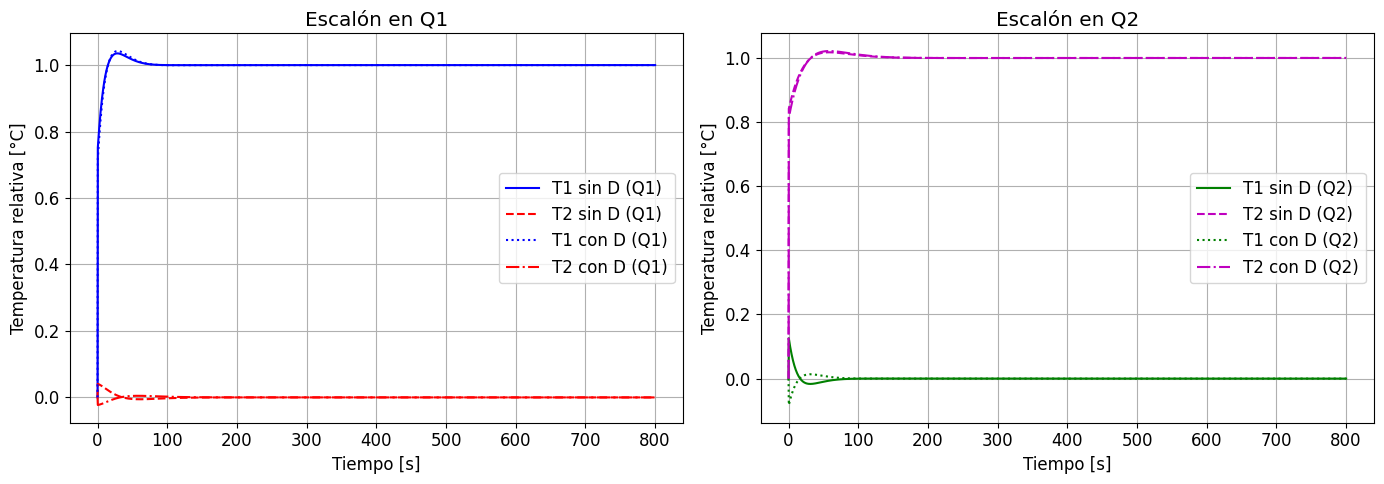

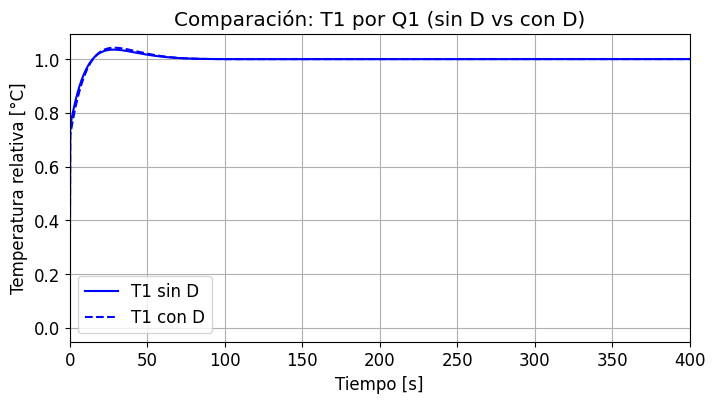

In [22]:
# === Gráficas comparativas: Sin desacoplador vs Con desacoplador ===
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':12})

# Comprobación de existencia de variables y manejo de fallback
try:
    t_plot = t_sim
    # Respuestas para escalón en Q1
    y11_sin = y11_no
    y21_sin = y21_no
    y11_con = y11_dec
    y21_con = y21_dec
    # Respuestas para escalón en Q2
    y12_sin = y12_no
    y22_sin = y22_no
    y12_con = y12_dec
    y22_con = y22_dec
except NameError:
    # Si las variables tienen otro nombre, intentar extraer de y_no / y_dec arrays
    try:
        t_plot = t_no if 't_no' in globals() else t_sim
        y11_sin = y_no[0,0,:]; y21_sin = y_no[1,0,:]
        y12_sin = y_no[0,1,:]; y22_sin = y_no[1,1,:]
        y11_con = y_dec[0,0,:]; y21_con = y_dec[1,0,:]
        y12_con = y_dec[0,1,:]; y22_con = y_dec[1,1,:]
    except Exception as e:
        raise RuntimeError('No se encontraron las variables de respuesta necesarias para graficar.') from e

# Plot: Escalón en Q1 (comparación)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(t_plot, y11_sin, 'b-', label='T1 sin D (Q1)')
ax1.plot(t_plot, y21_sin, 'r--', label='T2 sin D (Q1)')
ax1.plot(t_plot, y11_con, 'b:', label='T1 con D (Q1)')
ax1.plot(t_plot, y21_con, 'r-.', label='T2 con D (Q1)')
ax1.set_title('Escalón en Q1')
ax1.set_xlabel('Tiempo [s]')
ax1.set_ylabel('Temperatura relativa [°C]')
ax1.grid(True)
ax1.legend()

# Plot: Escalón en Q2 (comparación)
ax2.plot(t_plot, y12_sin, 'g-', label='T1 sin D (Q2)')
ax2.plot(t_plot, y22_sin, 'm--', label='T2 sin D (Q2)')
ax2.plot(t_plot, y12_con, 'g:', label='T1 con D (Q2)')
ax2.plot(t_plot, y22_con, 'm-.', label='T2 con D (Q2)')
ax2.set_title('Escalón en Q2')
ax2.set_xlabel('Tiempo [s]')
ax2.set_ylabel('Temperatura relativa [°C]')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

# Además, comparación directa T1 por Q1 (sin vs con)
plt.figure(figsize=(8,4))
plt.plot(t_plot, y11_sin, 'b-', label='T1 sin D')
plt.plot(t_plot, y11_con, 'b--', label='T1 con D')
plt.title('Comparación: T1 por Q1 (sin D vs con D)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Temperatura relativa [°C]')
plt.grid(True)
plt.legend()
plt.xlim([0, 400])
plt.show()
